In [98]:
import numpy as np
import tclab
import time
from datetime import datetime
import os
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from package_DBR import FOPDT,SOPDT,SelectPath_RT,myRound,Bode,Process
import package_DBR
import package12

In [99]:
nameFile = 'Data\Cleaned_data_Open_loop_experiment_on_MV_2025-03-10-14h08.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv(nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable) 

MV


# Variables

In [100]:
global a,Kp,T1,T2,Tu,Tg,Ts
a = (0.529-0.367)#temp dif 
Kp = 0.529 #without unit
T1 = 98 #sec
T2 = 120 #sec
Tu = 45 #sec
Tg = 170 #sec



# Variables of optimised FOPDT method

In [ ]:
# Final SSE Objective: 0.09221732478446891
# K: 0.5280686804191848
# T: 160.98841281582534
# theta: 35.21872295460488

# Variables of optimised SOPDT method

In [ ]:
# Final SSE Objective: 61.59653599275123
# K: 2.560132338489808
# T1: 1436.0596358826244
# T2: 766.3930696642674
# theta: 0.10817423141491614

# Variables of simulation

In [101]:
TSim = 720  # Simulation Time [s]
Ts = 1.0    # Sampling Period [s]

# Functions :

# Broida1

In [102]:
def broida1(MV): 
    PV = FOPDT(MV,Kp,Tg,Tu,Ts)
    return PV

# Broida2

In [103]:
def broida2(MV): 
    PV = FOPDT(MV,Kp,5.5*(T2-T1),(2.8*T1)-(1.8*T2),Ts)
    return PV

# VDG

In [104]:
def VDG(MV):
    global θ1,T1v,T2v
    e = 2.71828
    T1v = Tg*((3*a*e) - 1)/(1 +(a*e))
    T2v = Tg*(1-(a*e))/(1 +(a*e))
    θ1 = Tu - ((T1v * T2v)/(T1v+(3*T2v)))
    PV = SOPDT(MV,Kp,T1v,T2v,θ1,Ts)
    return PV

# Strejc 

In [105]:
def strejc(MV):
    global θ2,T
    Table_an = {1:0.00,2:0.10,3:0.22,4:0.32,5:0.41,6:0.49,7:0.57}
    Table_bn = {1:1.00,2:2.72,3:3.69,4:4.46,5:5.12,6:5.70,7:6.23}
    n = Tu/Tg

    for key, value in Table_an.items() : 
        if value <= n and n < Table_an[key+1] :
            nfinal = key

    an = Table_an[nfinal]
    bn = Table_bn[nfinal]

    T = Tg/bn
    Tuth = an*Tg
    θ2 = Tu - Tuth
    PV = FOPDT(MV,Kp,T,θ2,Ts)
    return PV

# Step response Comparaison 

(0.0, 1265.0)

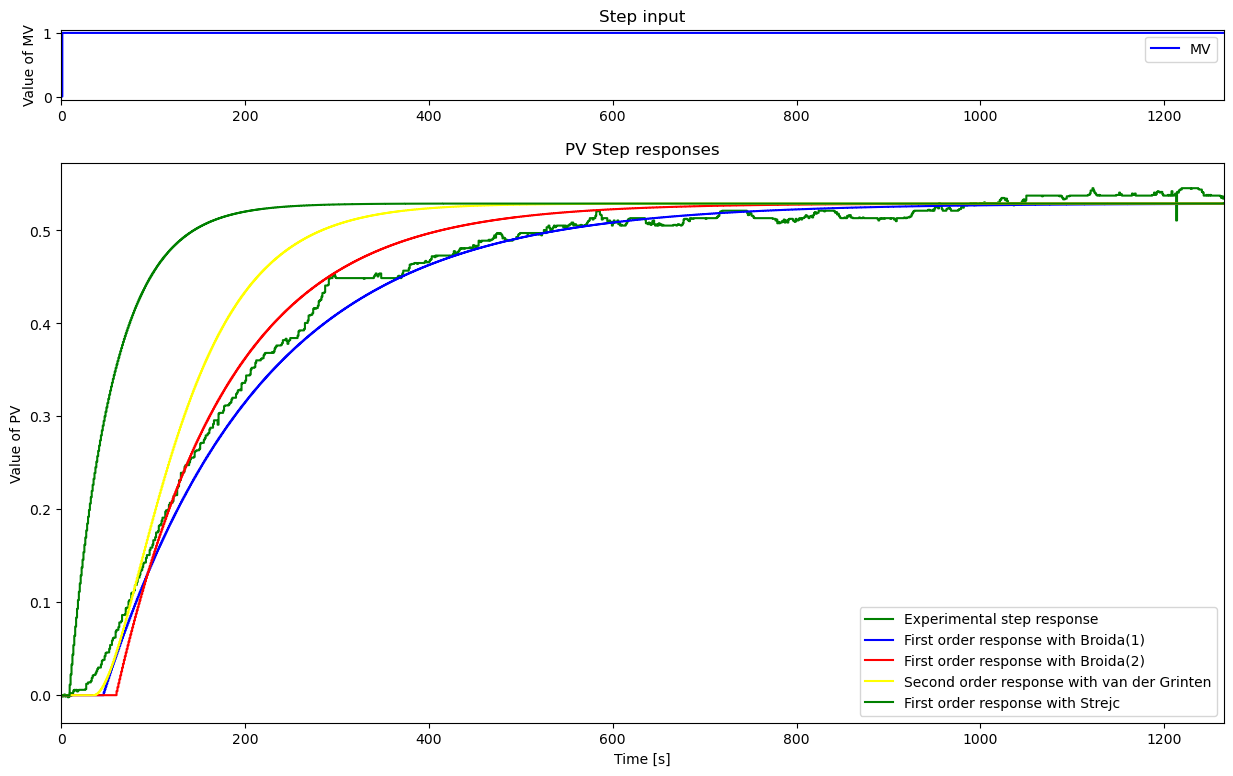

In [ ]:

broida1 = broida1(MVm)
broida2 = broida2(MVm)
VDG = VDG(MVm)
strejc = strejc(MVm)
broida_opt = FOPDT(MVm,0.5280686804191848,160.98841281582534,35.21872295460488,Ts)
VDG_opt = SOPDT(MVm,2.560132338489808,1436.0596358826244,766.3930696642674,0.10817423141491614,Ts)


fig, axs = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={'height_ratios': [1, 8]})

axs[0].step(tm, MVm, 'b-', label='MV', where='post')
axs[0].set_ylabel('Value of MV')
axs[0].set_title('Step input')
axs[0].legend(loc='best')
axs[0].set_xlim([0, np.max(tm)])

axs[1].step(tm, PVm, 'g-', label='Experimental step response', where='post')
axs[1].step(tm, broida1, 'b-', label='First order response with Broida(1)', where='post')
axs[1].step(tm, broida2, 'red', label='First order response with Broida(2)', where='post')
axs[1].step(tm, VDG, 'yellow', label='Second order response with van der Grinten', where='post')
axs[1].step(tm, strejc, 'green', label='First order response with Strejc', where='post')
axs[1].step(tm, broida_opt, 'black', label='First order response with Broida optimized', where='post')
axs[1].step(tm, VDG_opt, 'green', label='First order response with van der grinten optimised', where='post')

axs[1].set_ylabel('Value of PV')
axs[1].set_xlabel('Time [s]')
axs[1].set_title('PV Step responses')
axs[1].legend(loc='best')
axs[1].set_xlim([0, np.max(tm)])

# Bode diagram comparaison

Text(0, 0.5, 'Phase [°]')

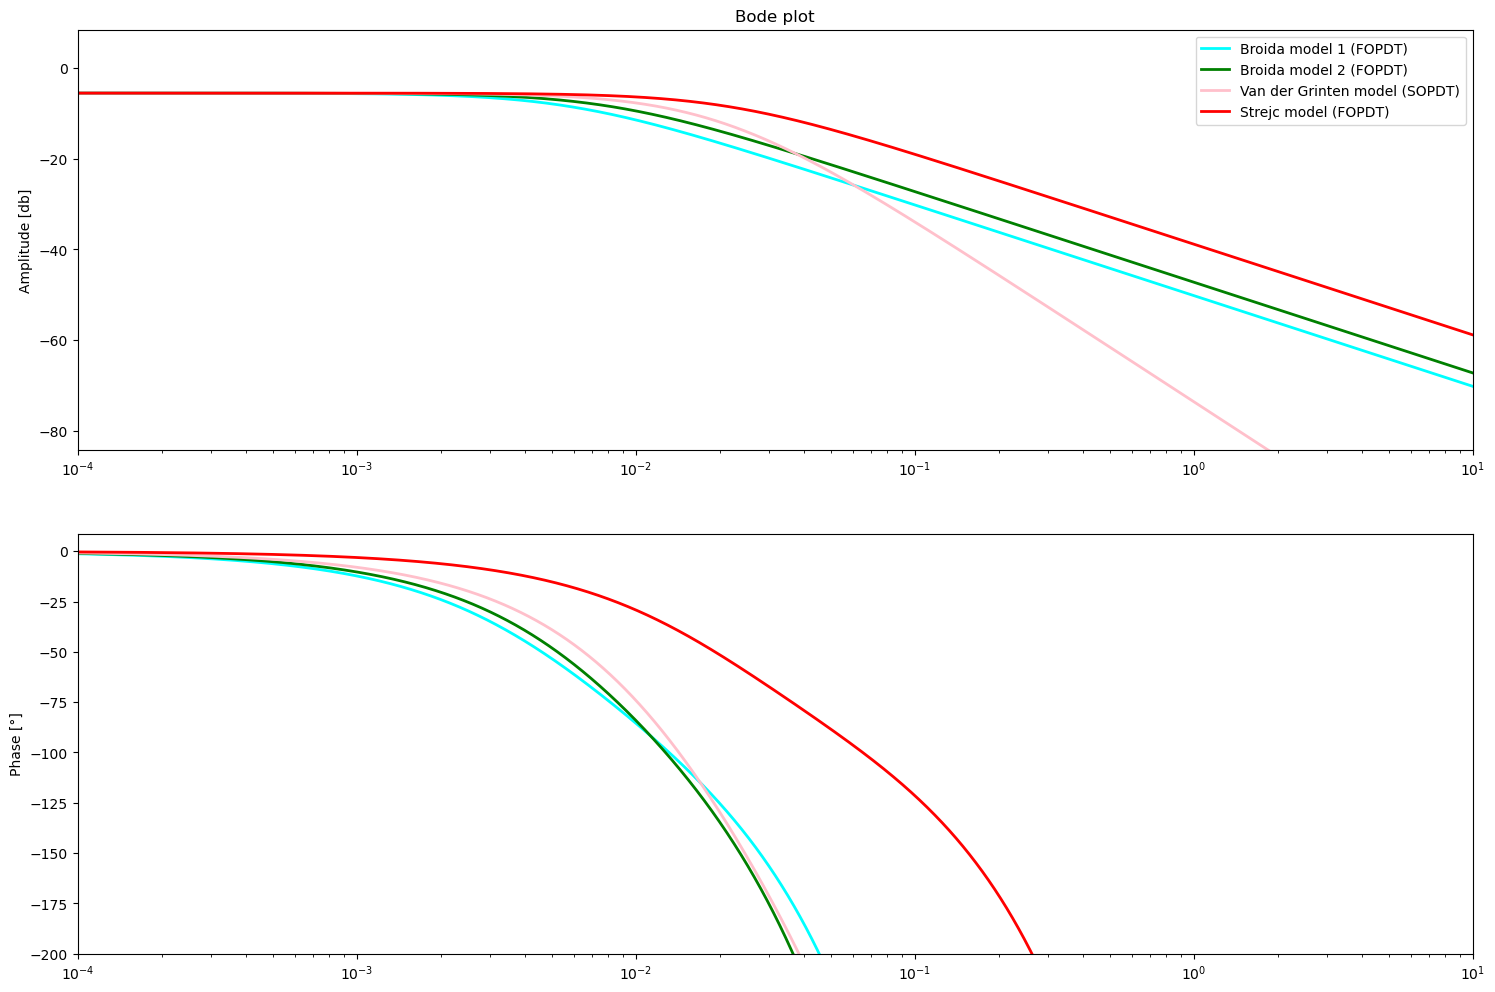

In [ ]:
P_broida1 = Process({}) 
P_broida1.parameters['Kp'] = Kp
P_broida1.parameters['Tlag1'] = Tg
P_broida1.parameters['theta'] = Tu

P_broida2 = Process({}) 
P_broida2.parameters['Kp'] = Kp
P_broida2.parameters['Tlag1'] = 5.5*(T2-T1)
P_broida2.parameters['theta'] = (2.8*T1)-(1.8*T2)

P_VDG = Process({}) 
P_VDG.parameters['Kp'] = Kp
P_VDG.parameters['Tlag1'] = T1v
P_VDG.parameters['Tlag2'] = T2v
P_VDG.parameters['theta'] = θ1


P_strejc = Process({}) 
P_strejc.parameters['Kp'] = Kp
P_strejc.parameters['Tlag1'] = T
P_strejc.parameters['theta'] = θ2

P_broida_opt = Process({})
P_broida_opt.parameters['Kp'] = 0.5280686804191848
P_broida_opt.parameters['Tlag1'] = 160.98841281582534
P_broida_opt.parameters['theta'] = 35.21872295460488

P_VDG_opt = Process({})
P_VDG_opt.parameters['Kp'] = 2.560132338489808
P_VDG_opt.parameters['Tlag1'] = 1436.0596358826244
P_VDG_opt.parameters['Tlag2'] = 766.3930696642674
P_VDG_opt.parameters['theta'] = 0.10817423141491614

omega = np.logspace(-4, 1, 10000)


Ps_broida1 = Bode(P_broida1,omega,False)
Ps_broida2 = Bode(P_broida2,omega,False)
Ps_VDG = Bode(P_VDG,omega,False)
Ps_strejc = Bode(P_strejc,omega,False)
Ps_broida_opt = Bode(P_broida_opt,omega,False)
Ps_VDG_opt = Bode(P_VDG_opt,omega,False)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_broida1)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_broida1)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_broida1)),'cyan',linewidth=2,label='Broida model 1 (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_broida2)),'green',linewidth=2,label='Broida model 2 (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_VDG)),'pink',linewidth=2,label='Van der Grinten model (SOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_strejc)),'red',linewidth=2,label='Strejc model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_broida_opt)),'black',linewidth=2,label='Broida optimized model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_VDG_opt)),'green',linewidth=2,label='Van der Grinten optimized model (SOPDT)')


plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_broida1))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_broida1))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_broida1)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_broida2)),'green',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_VDG)),'pink',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_strejc)),'red',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_broida_opt)),'black',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_VDG_opt)),'green',linewidth=2)



plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

# Data Save

In [ ]:
t = []
MV = []
PV = []
DV = []
# Save data in text file
# ----------------------
now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")
# Conversion to array
t = np.array(t) 
MV = np.array(MV)
PV = np.array(PV)
DV = np.array(DV)        
my_data = np.vstack((t.T,MV.T,PV.T,DV.T))
my_data = my_data.T
nameFile = 'Data/Simulation_OLP' + date_time + '.txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile,my_data,delimiter=',',header='t,MV,PV,DV',comments='')        


# Save Plot
# ---------
if not os.path.exists('Plots'):
    os.makedirs('Plots')

titleName = 'Simulation_OLP' + date_time
plt.savefig('Plots\\' + titleName + '.png',transparent=True)
plt.savefig('Plots\\' + titleName + '.pdf',transparent=True)  